In [ ]:
# Imports Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("CollegePlacement.csv")
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


<Axes: xlabel='CGPA', ylabel='IQ'>

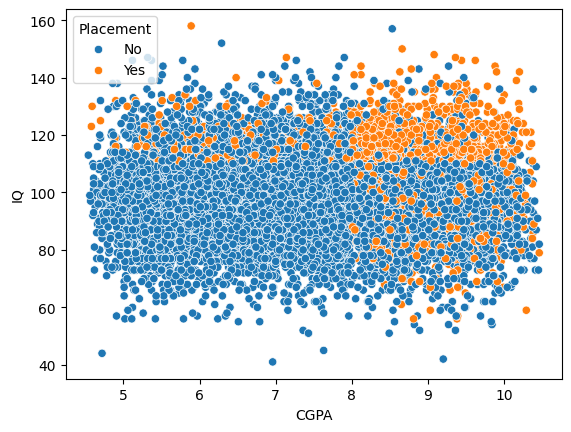

In [3]:
sns.scatterplot(x=df['CGPA'], y=df['IQ'], hue=df['Placement'])

In [4]:
# 1. Create a clean copy to avoid warnings
df_p = df[['CGPA', 'IQ', 'Placement']].copy()

# 2. Map the values (Ensure 'Yes'/'No' matches your data's capitalization)
df_p['Placement'] = df_p['Placement'].map({'Yes': 1, 'No': 0})

# 3. Define Features and Target
X = df_p[['CGPA', 'IQ']]
y = df_p['Placement']

# 4. Initialize and Train the Perceptron
from sklearn.linear_model import Perceptron
p = Perceptron()
p.fit(X, y) # Use uppercase X to match your variable

df_p.head()


,CGPA,IQ,Placement
0,6.28,107,0
1,5.37,97,0
2,5.83,109,0
3,5.75,122,0
4,7.69,96,0


In [5]:
# Standardizes CGPA and IQ
# Before it was not able to train perceptron properly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# p.fit(X,y)
# convert DataFrame to "name-less" array.
# p.fit(X.values, y.values)
p.fit(X_scaled, y.values)



,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [7]:
p.coef_

array([[0.44377487, 2.35656245]])

In [8]:
p.intercept_

array([-1.])

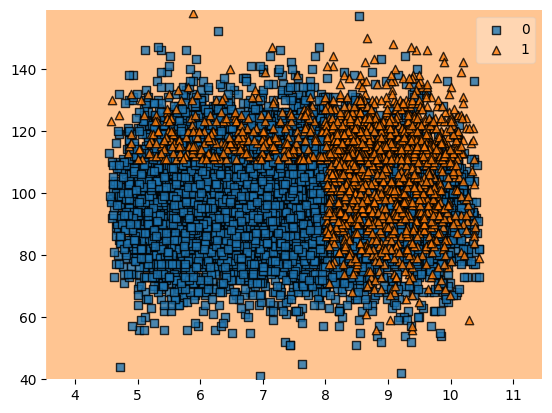

In [9]:
# Before Scaling
plot_decision_regions(X.values, y.values, clf=p)
plt.show()

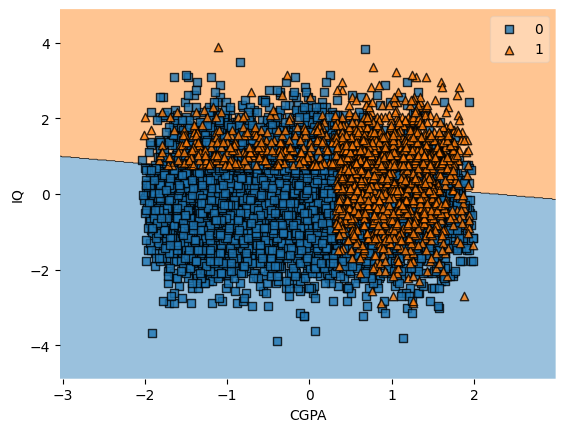

In [10]:
# After Scaling
plot_decision_regions(X_scaled, y.values, clf=p)
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.show()